# Numeric interferometer usage

**What you'll learn:**
- How to include wavenumber shifts in the numeric interferometer, i.e. from Gouy shifts or modulation frequency shifts.

First we need to import the needed libraries and define our interferometer geometry.

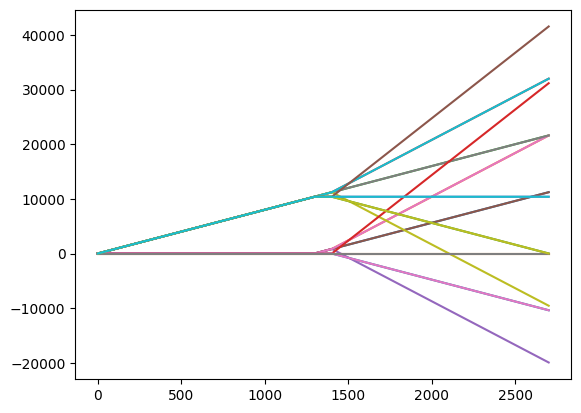

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

from mwave.numeric import NumericBraggInterferometer
from mwave.integrate import propagate, omega_fnc_gaussian, multi_omega_fnc, phase_fnc_constant
from mwave.utils.cloud import cloud_init
from mwave.utils.units import recoil

# Set interferometer parameters
nbragg = 4
T = recoil.time(100e-3)
Tp = recoil.time(8e-3)

# Initialize kvec and tree
ifr = NumericBraggInterferometer(-2*nbragg, 4*nbragg, distance=0) # Should pass in wavefunction initialization functions

# Define interferometer sequence
ifr.split(nbragg) # Should pass in the relevant function here as well! Function will inspect input function arguments to ensure correct number and naming
ifr.propagate(T)
ifr.split(nbragg)
ifr.propagate(Tp)
ifr.split([3*nbragg, -nbragg])
ifr.propagate(T)
ifr.split([3*nbragg, -nbragg])

# Get nodes and plot trajectories
nodes = ifr.get_nodes(x_tolerance=1e-11)
nA, nB, nC, nD = nodes[4*nbragg], nodes[2*nbragg], nodes[0.0*nbragg], nodes[-2*nbragg]
Ts = [0, 0, T, T, T + Tp, T + Tp, T + Tp + T, T + Tp + T]

plt.figure()
for nn in [nA, nB, nC, nD]:
    for p in nn:
        for node in nn[p]:
            t, x = node.get_trajectory()
            plt.plot(t, x)
plt.show()

This is our SCI along with all junk ports. To calculate the phase of the interferometer numerically we need a function with signature `function(*args, k_init, k_final, klattice, t, z)` to pass to the `ifr.compile` function. This function must compute the wavefunction amplitude in state `k_final` resulting from a Bragg transition with lattice at `klattice` for initial momentum state `k_init` at time `t` and position `z`. For now we will ignore the position. The function we write won't be completely general--it will only work for the values of `klattice` that we expect. Because of this, we will throw an error if we get an unexpected `klattice` value. Finally, we will define a function that acts as an "ideal" beamsplitter, and a function that actually integrates the Bragg dynamics.

In [2]:
# Define simulation parameters
Omega0 = 19.5
tol = 1e-6
tau_factor = 3
sigma = recoil.time(20e-6)
w0 = recoil.length(6.2e-3)

bs_lookup_dict = {}

def deltalookup(vz):
    # vz is in recoil velocity units, so it enters delta directly
    return 4*nbragg + 4*vz

def omegalookup(x, y):
    return Omega0*np.exp(-2*(x**2 + y**2)/(w0**2))

# Define beamsplitter function
def prop_bs_wavefunction_ideal(idx, x0, y0, vz, vx, vy, delta_phase_shift, omega_m, k_init, k_final, klattice, t, z):

    # Check if this is a multifrequency beamsplitter
    multifrequency = isinstance(klattice, list)

    # Check that this is a valid lattice
    if not multifrequency:
        assert klattice == nbragg
    else:
        assert len(klattice) == 2
        assert 3*nbragg in klattice
        assert -nbragg in klattice

    # Determine index of k_final state
    kf_idx = np.argmin(np.abs(ifr.kvec - k_final))
    
    # Determine atom number
    natoms = len(x0)

    # Return analtyic wavefunction amplitude
    if (k_final == 2*nbragg and k_init == 0) or (k_init == 2*nbragg and k_final == 0):
        return 1.0j/np.sqrt(2)*np.exp(1.0j*(-4*nbragg*t + delta_phase_shift)*(k_final - k_init)/2)
    elif (k_final == 4*nbragg and k_init == 2*nbragg) or (k_final == 2*nbragg and k_init == 4*nbragg):
        return 1.0j/np.sqrt(2)*np.exp(1.0j*(-(4*nbragg + omega_m)*t + delta_phase_shift)*(k_final - k_init)/2)
    elif (k_final == -2*nbragg and k_init == 0) or (k_final == 0 and k_init == -2*nbragg):
        return 1.0j/np.sqrt(2)*np.exp(1.0j*(-(4*nbragg - omega_m)*t + delta_phase_shift)*(k_final - k_init)/2)
    elif k_init == k_final:
        return 1.0/np.sqrt(2) + 0.0j
    else:
        return 0.0 + 0.0j

# Define beamsplitter function
def prop_bs_wavefunction_bragg(idx, x0, y0, vz, vx, vy, delta_phase_shift, omega_m, k_init, k_final, klattice, t, z):

    # Check if this is a multifrequency beamsplitter
    multifrequency = isinstance(klattice, list)

    # Check that this is a valid lattice
    if not multifrequency:
        assert klattice == nbragg
    else:
        assert len(klattice) == 2
        assert 3*nbragg in klattice
        assert -nbragg in klattice

    # Determine index of k_final state
    k0_idx = np.argmin(np.abs(ifr.kvec - k_init))
    kf_idx = np.argmin(np.abs(ifr.kvec - k_final))
    
    # Determine atom number
    natoms = len(x0)
    # Load cached result
    if idx in bs_lookup_dict:
        if k_init in bs_lookup_dict[idx]:
            return bs_lookup_dict[idx][k_init][:, kf_idx] if natoms > 1 else bs_lookup_dict[idx][k_init][kf_idx]

    # Compute omegas and deltas
    x = x0 + vx*t
    y = y0 + vy*t
    omegas = omegalookup(x, y)
    deltas = deltalookup(vz)

    # Create phi0
    phi0 = np.zeros_like(ifr.kvec, dtype=np.complex128)
    phi0[k0_idx] = 1.0 + 0.0j

    if natoms > 1:
        phi0 = np.tile(phi0, (natoms, 1))
    else:
        deltas = deltas[0]
        omegas = omegas[0]

    # Integrate
    if not multifrequency:
        result = propagate(
            ifr.kvec, phi0, t + 2*tau_factor*sigma, deltas,
            omega_fnc_gaussian, np.array([1.0, sigma, t + tau_factor*sigma]),
            phase_fnc_constant, np.array([delta_phase_shift]),
            omegas=omegas, t0=t, tol=tol
        )
    else:
        result = propagate(
            ifr.kvec, phi0, t + 2*tau_factor*sigma, deltas,
            multi_omega_fnc, np.array([1.0, sigma, t + tau_factor*sigma, omega_m]),
            phase_fnc_constant, np.array([delta_phase_shift]),
            omegas=omegas, t0=t, tol=tol
        )

    # Save result
    phi = result.phi_final

    # Save wavefunction to cache
    if idx not in bs_lookup_dict:
        bs_lookup_dict[idx] = {}
    if k_init not in bs_lookup_dict[idx]:
        bs_lookup_dict[idx][k_init] = phi
    else:
        raise RuntimeError('Array should not have been created but it was!')

    # Return
    return bs_lookup_dict[idx][k_init][:, kf_idx] if natoms > 1 else bs_lookup_dict[idx][k_init][kf_idx]

Now we will compile the interferometer using the function we have defined above along with the function that describes how phase accumulates during free propagation (this is a trivial function). The `NumericBraggInterferometer` class will automatically call the beamsplitter function we have defined at each split, and the propagation function during the propagation steps. We will wrap the compile function in a function called `sim_ellipse` that accepts a phase (supposedly coming from vibrations that shift the phase of the third Bragg pulse), and a modulation frequency. It will return the `x` and `y` location of the ellipse shot for the provided `vibration_phase` and `omega_m`.

In [3]:
def sim_ellipse(vibration_phase, omega_m, use_ideal=False):

    prop_bs_wavefunction = prop_bs_wavefunction_ideal if use_ideal else prop_bs_wavefunction_bragg

    split_funcs = [
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: prop_bs_wavefunction(0, x0, y0, vz, vx, vy, 0.0, omega_m, k_init, k_final, klattice, t, z),
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: prop_bs_wavefunction(1, x0, y0, vz, vx, vy, 0.0, omega_m, k_init, k_final, klattice, t, z),
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: prop_bs_wavefunction(2, x0, y0, vz, vx, vy, vibration_phase, omega_m, k_init, k_final, klattice, t, z),
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: prop_bs_wavefunction(3, x0, y0, vz, vx, vy, 0.0, omega_m, k_init, k_final, klattice, t, z)
    ]

    propagate_func = lambda x0, y0, vz, vx, vy, t, k: np.exp(-1j*t*k**2)

    kvector_funcs = [
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: 0.0,
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: 0.0,
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: 0.0,
        lambda x0, y0, vz, vx, vy, k_init, k_final, klattice, t, z: 0.0,
    ]

    output_momenta = [4*nbragg, 2*nbragg, 0*nbragg, -2*nbragg]

    popfunc = ifr.compile(split_funcs=split_funcs,
                        propagate_func=propagate_func,
                        output_momentums=output_momenta,
                        kvector_funcs=kvector_funcs,
                        x_tolerance=1e-11)

    def xyfunc(x0, y0, vz, vx, vy):
        pA, pB, pC, pD = popfunc(4*nbragg, [x0, y0, vz, vx, vy]), popfunc(2*nbragg, [x0, y0, vz, vx, vy]), popfunc(0*nbragg, [x0, y0, vz, vx, vy]), popfunc(-2*nbragg, [x0, y0, vz, vx, vy])
        return (pB-pA)/(pB+pA), (pD-pC)/(pD+pC)

    # Cloud parameters supplied in recoil units: lengths in L_r, velocities in v_r
    x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=recoil.length(1e-3), sigma_transverse_v=1.5, sigma_vertical_v=0.1, seed=137)
    x, y = xyfunc(x0, y0, vz, vx, vy)
    x, y = np.mean(x), np.mean(y)

    return x, y

Now, keeping the vibration phase fixed, we will scan the modulation frequency for the ideal beamsplitter case. From Brian Estey's thesis Eq.(2.27) and the unlabeled equation preceeding Eq.(2.27) we also know what phase we expect analytically for both `x` and `y`. We plot these alongside the numerically computed phase.

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 551.67it/s]


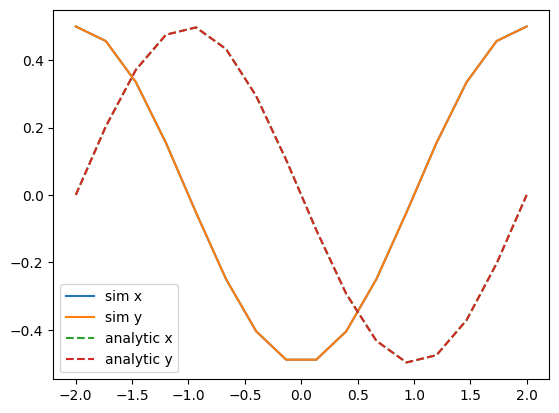

In [4]:
# Define analytic form of x and y
def analytic_ellipse(vibration_phase, omega_m):
    phid = 8*nbragg**2*T - nbragg*omega_m*T
    phic = vibration_phase
    pA = np.cos((phic+phid)/2)**2/8
    pB = np.cos((phic-phid)/2)**2/8
    pC = np.sin((phic-phid)/2)**2/8
    pD = np.sin((phic+phid)/2)**2/8
    return (pB-pA)/(pB+pA)/2, (pD-pC)/(pD+pC)/2

# Define phases to scan over
target_phases = np.linspace(-2*np.pi, 2*np.pi, 16)
omega_ms = 8*nbragg + target_phases/(2*nbragg*T)

# Loop over each modulation frequency, compute x and y
x, y = np.full_like(omega_ms, np.nan), np.full_like(omega_ms, np.nan)
ax, ay = np.full_like(omega_ms, np.nan), np.full_like(omega_ms, np.nan)
for i in tqdm(range(len(omega_ms))):
    bs_lookup_dict = {} # Reset cache
    x[i], y[i] = sim_ellipse(0.0, omega_ms[i], use_ideal=True)
    ax[i], ay[i] = analytic_ellipse(np.pi/2, omega_ms[i])

# Plot
plt.plot(target_phases/np.pi, x, label='sim x')
plt.plot(target_phases/np.pi, y, label='sim y')
plt.plot(target_phases/np.pi, ax, '--', label='analytic x')
plt.plot(target_phases/np.pi, ay, '--', label='analytic y')
plt.legend()
plt.show()

The periods agree, but it seems we have a phase offset of $\pi/4$ between the two. Not sure why this is.

Moving along to an ellipse

100%|██████████| 16/16 [00:00<00:00, 374.28it/s]


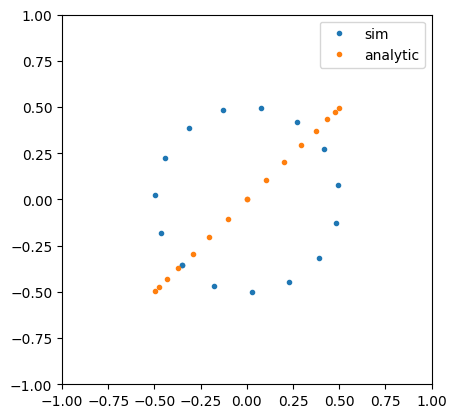

In [5]:
# Define phases to scan over, select opening phase of pi/2
omega_m = 8*nbragg - np.pi/2/(2*nbragg*T)
vibration_phases = np.linspace(0, 2*np.pi/nbragg, 16)

# Loop over each vibration phase, compute x and y
x, y = np.full_like(vibration_phases, np.nan), np.full_like(vibration_phases, np.nan)
ax, ay = np.full_like(omega_ms, np.nan), np.full_like(omega_ms, np.nan)
for i in tqdm(range(len(vibration_phases))):
    bs_lookup_dict = {}
    x[i], y[i] = sim_ellipse(vibration_phases[i], omega_m, use_ideal=True)
    ax[i], ay[i] = analytic_ellipse(np.pi/2, omega_ms[i])

plt.plot(x, y, '.', label='sim')
plt.plot(ax, ay, '.', label='analytic')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

Strangely the analytic case also seems wrong here, as we expect an open ellipse when the target phase is $\pi/2$. I think this might come from Brian's thesis leaving out the $\pi/2$ phase shift that you get from each beamsplitter (this is included in the symbolic interferometer calculation in `mwave`, could compare to that). Anyhow, this seems reasonable enough to me.

Now lets generate the same plots but with actual Bragg beamsplitters and 1000 atoms.

100%|██████████| 16/16 [00:10<00:00,  1.50it/s]


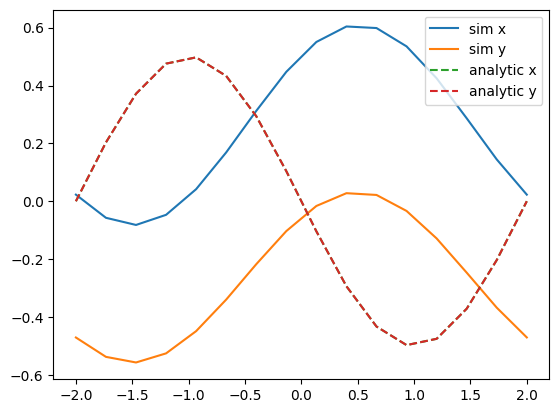

100%|██████████| 16/16 [00:10<00:00,  1.51it/s]


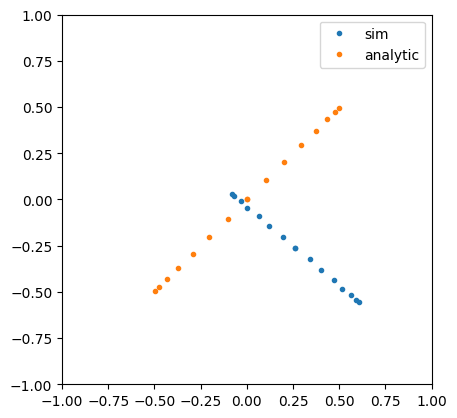

In [6]:
# Define phases to scan over
target_phases = np.linspace(-2*np.pi, 2*np.pi, 16)
omega_ms = 8*nbragg + target_phases/(2*nbragg*T)

# Loop over each modulation frequency, compute x and y
x, y = np.full_like(omega_ms, np.nan), np.full_like(omega_ms, np.nan)
ax, ay = np.full_like(omega_ms, np.nan), np.full_like(omega_ms, np.nan)
for i in tqdm(range(len(omega_ms))):
    bs_lookup_dict = {} # Reset cache
    x[i], y[i] = sim_ellipse(0.0, omega_ms[i], use_ideal=False)
    ax[i], ay[i] = analytic_ellipse(np.pi/2, omega_ms[i])

# Plot
plt.plot(target_phases/np.pi, x, label='sim x')
plt.plot(target_phases/np.pi, y, label='sim y')
plt.plot(target_phases/np.pi, ax, '--', label='analytic x')
plt.plot(target_phases/np.pi, ay, '--', label='analytic y')
plt.legend()
plt.show()

# Define phases to scan over, select opening phase of pi/2
omega_m = 8*nbragg - np.pi/2/(2*nbragg*T)
vibration_phases = np.linspace(0, 2*np.pi/nbragg, 16)

# Loop over each vibration phase, compute x and y
x, y = np.full_like(vibration_phases, np.nan), np.full_like(vibration_phases, np.nan)
ax, ay = np.full_like(omega_ms, np.nan), np.full_like(omega_ms, np.nan)
for i in tqdm(range(len(vibration_phases))):
    bs_lookup_dict = {}
    x[i], y[i] = sim_ellipse(vibration_phases[i], omega_m, use_ideal=False)
    ax[i], ay[i] = analytic_ellipse(np.pi/2, omega_ms[i])

plt.plot(x, y, '.', label='sim')
plt.plot(ax, ay, '.', label='analytic')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.legend()
plt.gca().set_aspect('equal')
plt.show()